# Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from matplotlib import rc
xscaler = MinMaxScaler()

In [2]:
file_path = '../../input_data/pspeo_master.xlsx'
model_output = 'domain'
# import data frame for pre-processing
df = pd.read_excel(file_path)
df.head()

,sample,solv_ratio,add_type,swell_ratio,gisaxs_domain,gisaxs_fwhm,afm_domain,afm_grain
0,I_A_AC,80/20,Chloronaphthalene,1.00,31.302630,0.003697,33.737303,0.0048
1,I_A025,80/20,Chloronaphthalene,1.25,33.805848,0.003136,35.151690,0.0047
2,I_A050,80/20,Chloronaphthalene,1.50,34.176062,0.002970,35.397797,0.0534
3,I_A075,80/20,Chloronaphthalene,1.75,34.383751,0.003451,34.603726,0.0425
4,I_A_100,80/20,Chloronaphthalene,2.00,31.674148,0.005122,33.786210,0.0244


# Data pre-processing

In [3]:
# Assign input variables and target variable, eliminating static valuesp
inputs = df.loc[:, ['solv_ratio', 'swell_ratio', 'add_type']]
target = df['gisaxs_domain']

# Define mapping for solv_ratio
type_mapping = {100: 1.0, '90/10': 0.9, '80/20': 0.8, '70/30': 0.7, '60/40': 0.6, '50/50': 0.5}
inputs['solv_ratio'] = inputs['solv_ratio'].replace(type_mapping)

# Encode categorical input 'add_type'
le_addType = LabelEncoder()
inputs['add_type'] = le_addType.fit_transform(inputs['add_type'])

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=10)

# Scale the x data for better fitting
xscaler.fit(X_train)
X_train = xscaler.transform(X_train)
X_test = xscaler.transform(X_test)

In [4]:
print(len(X_train))

161


# Grid-Search

Best Average R² (CV Train + Test): 0.7188742935845496
CV Train R²: 0.6328984621885404
Test R²: 0.8048501249805587
Best Parameters: {'bootstrap': False, 'criterion': 'squared_error', 'max_depth': 30, 'max_features': 'log2', 'max_leaf_nodes': 50, 'min_samples_split': 10, 'n_estimators': 50}

Generating learning curve...


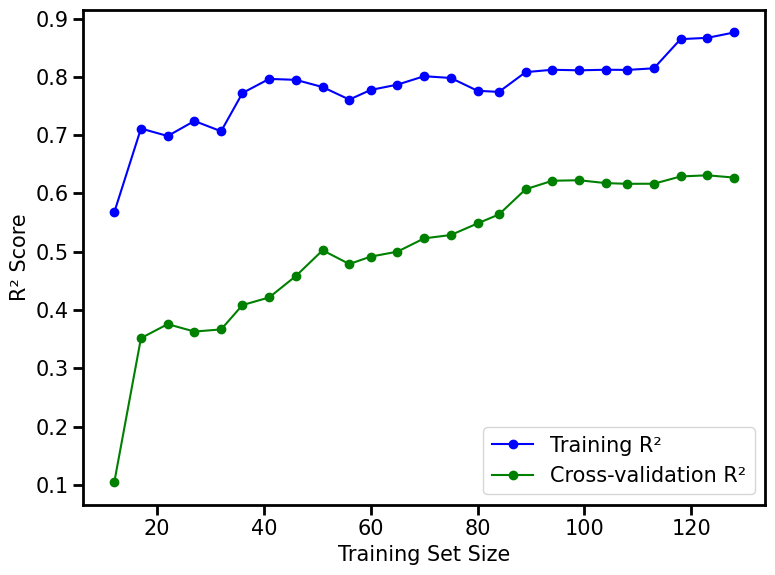

CPU times: user 504 ms, sys: 186 ms, total: 690 ms
Wall time: 1.88 s


In [5]:
%%time

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, ParameterGrid, learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Define parameter grid
param_grid = {
    'n_estimators': [50],
    'criterion': ["squared_error"],
    'max_depth': [30],
    'min_samples_split': [10],
    'max_leaf_nodes': [50],
    'max_features': ['log2'],  # 1.0 = use all features
    'bootstrap': [False]
}

RANDOM_SEED = 42
CV_FOLDS = 5

# Store the best results
best_model = None
best_params = None
best_avg_r2 = float('-inf')

# Grid search
for params in ParameterGrid(param_grid):
    model = RandomForestRegressor(**params, random_state=RANDOM_SEED, n_jobs=-1)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=-1)
    cv_r2 = np.mean(cv_scores)
    
    model.fit(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    avg_r2 = (cv_r2 + test_r2) / 2

    if avg_r2 > best_avg_r2:
        best_avg_r2 = avg_r2
        best_model = model
        best_params = params
        best_cv_r2 = cv_r2
        best_test_r2 = test_r2

# Output the best results
print("Best Average R² (CV Train + Test):", best_avg_r2)
print("CV Train R²:", best_cv_r2)
print("Test R²:", best_test_r2)
print("Best Parameters:", best_params)

# ------------------------------------------------------------
# Learning curve on best model configuration
# ------------------------------------------------------------
print("\nGenerating learning curve...")

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=RandomForestRegressor(**best_params, random_state=RANDOM_SEED, n_jobs=-1),
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 25),
    cv=CV_FOLDS,
    scoring='r2',
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_SEED
)

train_scores_mean = np.mean(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)

# set formatting for plots
%matplotlib inline
# from matplotlib import cm
from matplotlib import rc
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=15)  
rc('xtick.major', size=7)   
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=15)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=15) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True})   

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training R²')
plt.plot(train_sizes, valid_scores_mean, 'o-', color='green', label='Cross-validation R²')
# plt.title('Learning Curve (Best RF)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend(loc='best')
plt.grid(False)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=500)
plt.show()

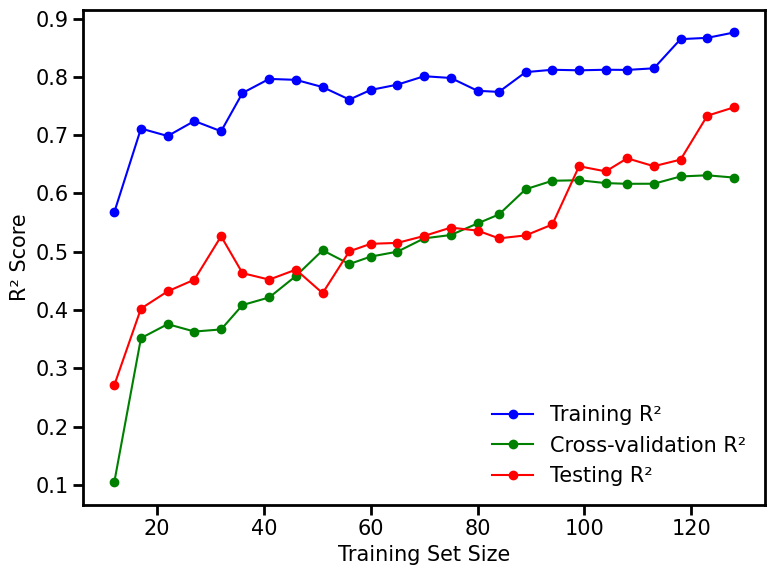

In [6]:
from sklearn.utils import resample

test_scores = []

for size in train_sizes:
    # Get integer count of samples
    n_samples = int(size)
    
    # Sample without replacement from the training set
    X_sub, y_sub = resample(X_train, y_train, replace=False, n_samples=n_samples, random_state=RANDOM_SEED)
    
    # Fit model
    model = RandomForestRegressor(**best_params, random_state=RANDOM_SEED, n_jobs=-1)
    model.fit(X_sub, y_sub)
    
    # Evaluate on the fixed test set
    r2_test = model.score(X_test, y_test)
    test_scores.append(r2_test)

test_scores = np.array(test_scores)

# Plotting all three curves
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training R²')
plt.plot(train_sizes, valid_scores_mean, 'o-', color='green', label='Cross-validation R²')
plt.plot(train_sizes, test_scores, 'o-', color='red', label='Testing R²')

plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend(loc='best', frameon=False)
plt.grid(False)
plt.tight_layout()
plt.savefig('ds_learning_curve_with_test.pdf', format='pdf', transparent=True)
plt.show()

In [16]:
test_scores

array([0.27069936, 0.40239778, 0.43199016, 0.45206718, 0.52648055,
       0.46322994, 0.452099  , 0.46924109, 0.42885844, 0.50067467,
       0.51354712, 0.51512804, 0.52706009, 0.54135268, 0.53624471,
       0.52290199, 0.52800205, 0.54670953, 0.6466686 , 0.63782328,
       0.66028351, 0.64672205, 0.65805937, 0.73339796, 0.74781243])

In [1]:
best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best.fit(X_train, y_train)
# test_r2 = model.score(X_test, y_test)  # or use r2_score(y_test, model.predict(X_test))

NameError: name 'RandomForestRegressor' is not defined

In [6]:
train_r2 = best.score(X_train, y_train)
test_r2 = best.score(X_test, y_test)

print(f'Training r2: {train_r2}')
print(f'Testing r2: {test_r2}')

# Create an array for x values
x_len = len(y_test)
actual_x = np.arange(1, x_len+1)

# Define the output path for figures
output_path = f'../final_figs/{model_output}/'

Training r2: 0.9062864488952616
Testing r2: 0.8048501249805591


In [7]:
from joblib import dump, load

dump(best, f'{model_output}.joblib')

['domain.joblib']

In [8]:
rfr_train = best.predict(X_train)
rfr_test = best.predict(X_test)

# Visualize the results

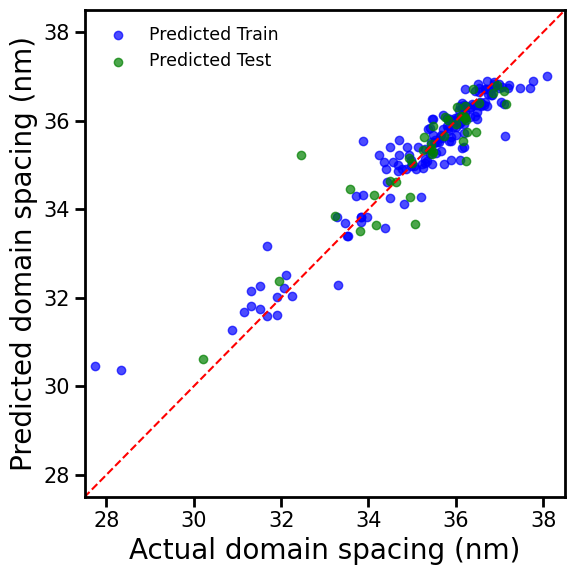

In [15]:
# Define the figure title
fig_title = f'{model_output}_avp.png'

# set formatting for plots
%matplotlib inline
# from matplotlib import cm
from matplotlib import rc
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=15)  
rc('xtick.major', size=7)   
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=15)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=15) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True})   


plt.figure(figsize=(6, 6))
# Create a scatter plot
plt.scatter(y_train, rfr_train, color='blue', label='Predicted Train', alpha=0.7)
plt.scatter(y_test, rfr_test, color='green', label='Predicted Test', alpha=0.7)

# Add a diagonal line for reference (perfect prediction)
plt.plot([0, 100], [0, 100], linestyle='--', color='red')

# Add labels and a legend
plt.xlabel('Actual domain spacing (nm)', fontsize='20')
plt.ylabel('Predicted domain spacing (nm)', fontsize='20')

# Set legend background color to white
legend = plt.legend(fontsize='12.5', frameon=False)
legend.get_frame().set_facecolor('white')

# Set the background color to white
plt.gca().set_facecolor('white')

# Remove gridlines
plt.grid(False)

# Add tickmarks to x and y axes
plt.tick_params(axis='both', which='both', reset=True, top=False, right=False)

plt.xlim(27.5, 38.5)
plt.ylim(27.5, 38.5)

# # Add black borders to the grid
plt.gca().spines['top'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['right'].set_color('black')

# Show the plot
plt.tight_layout()
# plt.savefig(output_path + fig_title, dpi=500, format='png')
plt.show()

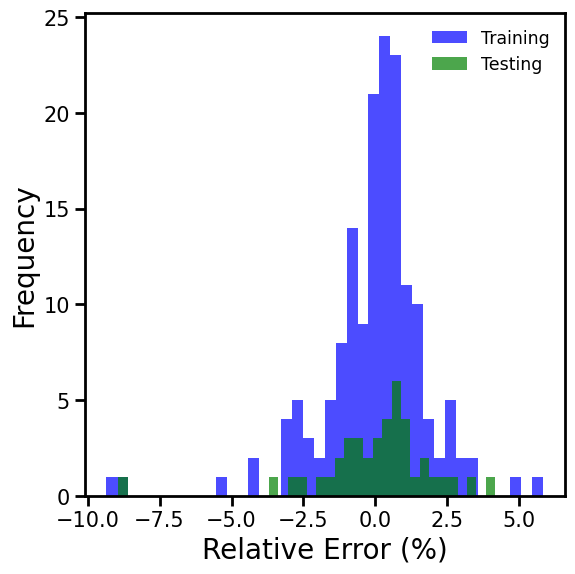

In [47]:
# Define the figure title
fig_title = f'{model_output}_relative_error_histogram.png'

# Calculate relative error as percent
rel_err_train_pct = 100 * (y_train - rfrtrain) / y_train
rel_err_test_pct = 100 * (y_test - rfreval) / y_test

# set formatting for plots
%matplotlib inline
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=15)  
rc('xtick.major', size=7)   
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=15)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=15) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True})   

# Create a histogram of relative errors
plt.figure(figsize=(6, 6))
bins = 40  # adjust as needed
plt.hist(rel_err_train_pct, bins=bins, alpha=0.7, color='blue', label='Training')
plt.hist(rel_err_test_pct, bins=bins, alpha=0.7, color='green', label='Testing')

plt.xlabel("Relative Error (%)", fontsize='20')
plt.ylabel("Frequency", fontsize='20')

# Set legend background color to white
legend = plt.legend(fontsize='12.5', frameon = False)
legend.get_frame().set_facecolor('white')

# Set the background color to white
plt.gca().set_facecolor('white')

# Remove gridlines
plt.grid(False)

# Add tickmarks to x and y axes
plt.tick_params(axis='both', which='both', reset=True, top=False, right=False)

# Add black borders to the plot
plt.gca().spines['top'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['right'].set_color('black')

plt.tight_layout()
plt.savefig(output_path + fig_title, dpi=500, format='png')
plt.show()

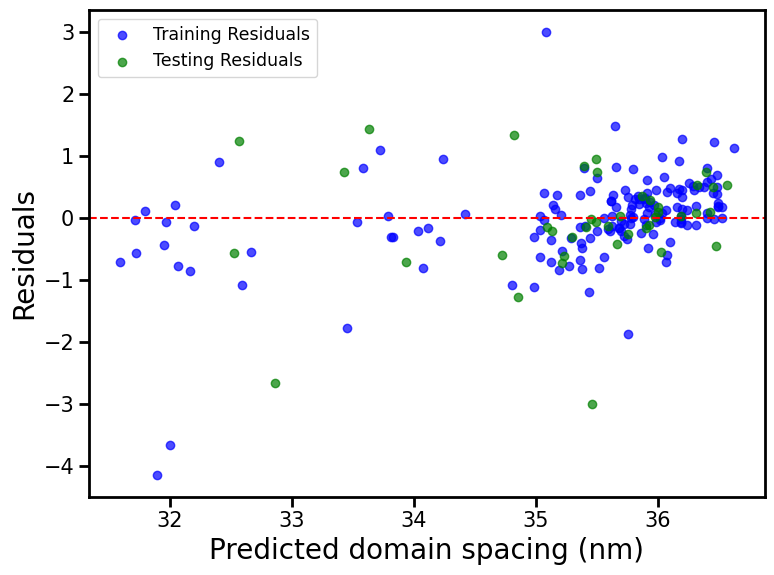

In [31]:
# Define the figure title
fig_title = f'{model_output}_residuals.png'

res_train = y_train - rfrtrain
res_test = y_test - rfreval

# set formatting for plots
%matplotlib inline
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=15)  
rc('xtick.major', size=7)   
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=15)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=15) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True})   

# Create a residuals plot
plt.figure(figsize=(8, 6))
plt.scatter(rfrtrain, res_train, color='blue', alpha=0.7, label='Training Residuals')
plt.scatter(rfreval, res_test, color='green', alpha=0.7, label='Testing Residuals')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted domain spacing (nm)", fontsize='20')
plt.ylabel("Residuals", fontsize='20')
# Set legend background color to white
legend = plt.legend(fontsize='12.5')
legend.get_frame().set_facecolor('white')

# Set the background color to white
plt.gca().set_facecolor('white')

# Remove gridlines
plt.grid(False)

# Add tickmarks to x and y axes
plt.tick_params(axis='both', which='both', reset=True, top=False, right=False)

# # Add black borders to the grid
plt.gca().spines['top'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['right'].set_color('black')

plt.grid(False)
plt.tight_layout()
# plt.savefig(output_path + fig_title, format='png')
plt.show()